# PraUAS

## Pendahuluan

Kanker payudara adalah salah satu jenis kanker yang paling umum dan mematikan di seluruh dunia, terutama di kalangan wanita. Deteksi dini kanker payudara sangat penting untuk meningkatkan peluang penyembuhan dan mengurangi angka kematian. Salah satu metode diagnostik modern yang digunakan adalah analisis fitur dari citra digital hasil *Fine Needle Aspirate* (FNA) dari massa payudara.

Fitur-fitur ini, seperti radius, tekstur, dan area inti sel, memberikan informasi kuantitatif yang dapat membantu membedakan antara massa jinak (benign) dan ganas (malignant). Penilaian ini membantu dalam menilai risiko keganasan dan menentukan langkah diagnostik atau terapeutik yang tepat, sering kali dengan bantuan model *machine learning*.

## Data Understanding

### Sumber Data

Dataset diambil dari link dibawah ini:

https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

Dataset Breast Cancer Wisconsin (Diagnostic) yang tersedia di UCI Machine Learning Repository berasal dari University of Wisconsin Hospitals, Madison, dan dibuat oleh Dr. William H. Wolberg, W. Nick Street, dan Olvi L. Mangasarian.

#### Tujuan

Dataset ini digunakan untuk mengembangkan model prediktif yang mampu mengklasifikasikan massa payudara sebagai jinak (benign) atau ganas (malignant) berdasarkan fitur-fitur inti sel yang diekstraksi dari citra digital, yang sangat membantu dalam penelitian dan diagnosis medis berbantuan komputer.

#### Integrasi Data

Untuk mengambil data agar dapat diolah, perlu untuk menginstall package yang telah disediakan oleh UCI Dataset. Instalasi dilakukan berguna untuk menarik data yang berasal dari UCI dataset agar dapat diolah. Perintah untuk mengambil data dari UCI dataset dapat di lihat ketika menekan tombol "import in python" pada dataset yang diinginkan dan ikuti perintah tersebut agar data dapat diambil dari UCI dataset.

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

## data (as pandas dataframes)
data = breast_cancer_wisconsin_diagnostic.data.original
  # menyimpan hasil komputasi ke dalam csv
data.to_csv("breast_cancer_diagnostic.csv", index=True)
print(data.info()) #untuk menampilkan info fitur-fitur yang ada di tabel

print(data.head()) #untuk menampilkan 5 baris pertama

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  569 non-null    int64  
 1   radius1             569 non-null    float64
 2   texture1            569 non-null    float64
 3   perimeter1          569 non-null    float64
 4   area1               569 non-null    float64
 5   smoothness1         569 non-null    float64
 6   compactness1        569 non-null    float64
 7   concavity1          569 non-null    float64
 8   concave_points1     569 non-null    float64
 9   symmetry1           569 non-null    float64
 10  fractal_dimension1  569 non-null    float64
 11  radius2             569 non-null    float64
 12  texture2            569 non-null    float64
 13  perimeter2          569 non-null    float64
 14  area2               569 non-null    float64
 15  smoothness2         569 non-null    float64
 16  compactn

### Eksplorasi Data

#### Visualisasi Data

In [ ]:
display(data) #display dataset

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,M
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,M
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,M
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,M
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,M
565,926682,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,M
566,926954,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,M
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,M


/tmp/ipython-input-25-959777028.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diagnosis', data=data, palette='viridis')


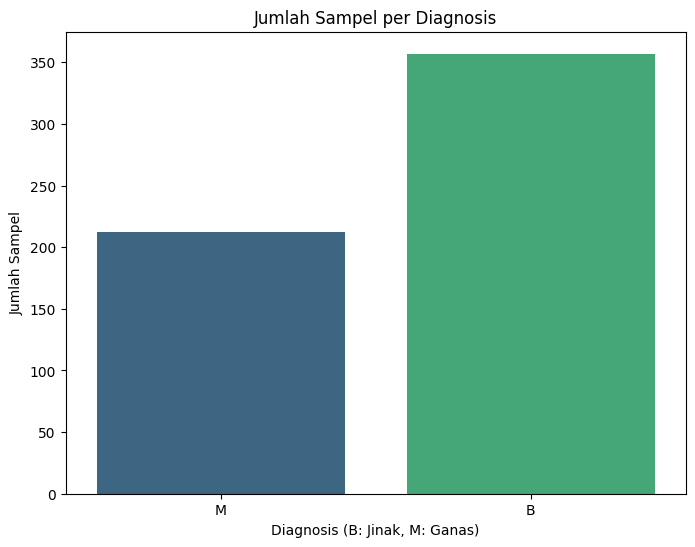

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.countplot(x='Diagnosis', data=data, palette='viridis')
plt.title('Jumlah Sampel per Diagnosis')
plt.xlabel('Diagnosis (B: Jinak, M: Ganas)')
plt.ylabel('Jumlah Sampel')
plt.show()

<Figure size 2000x1500 with 0 Axes>

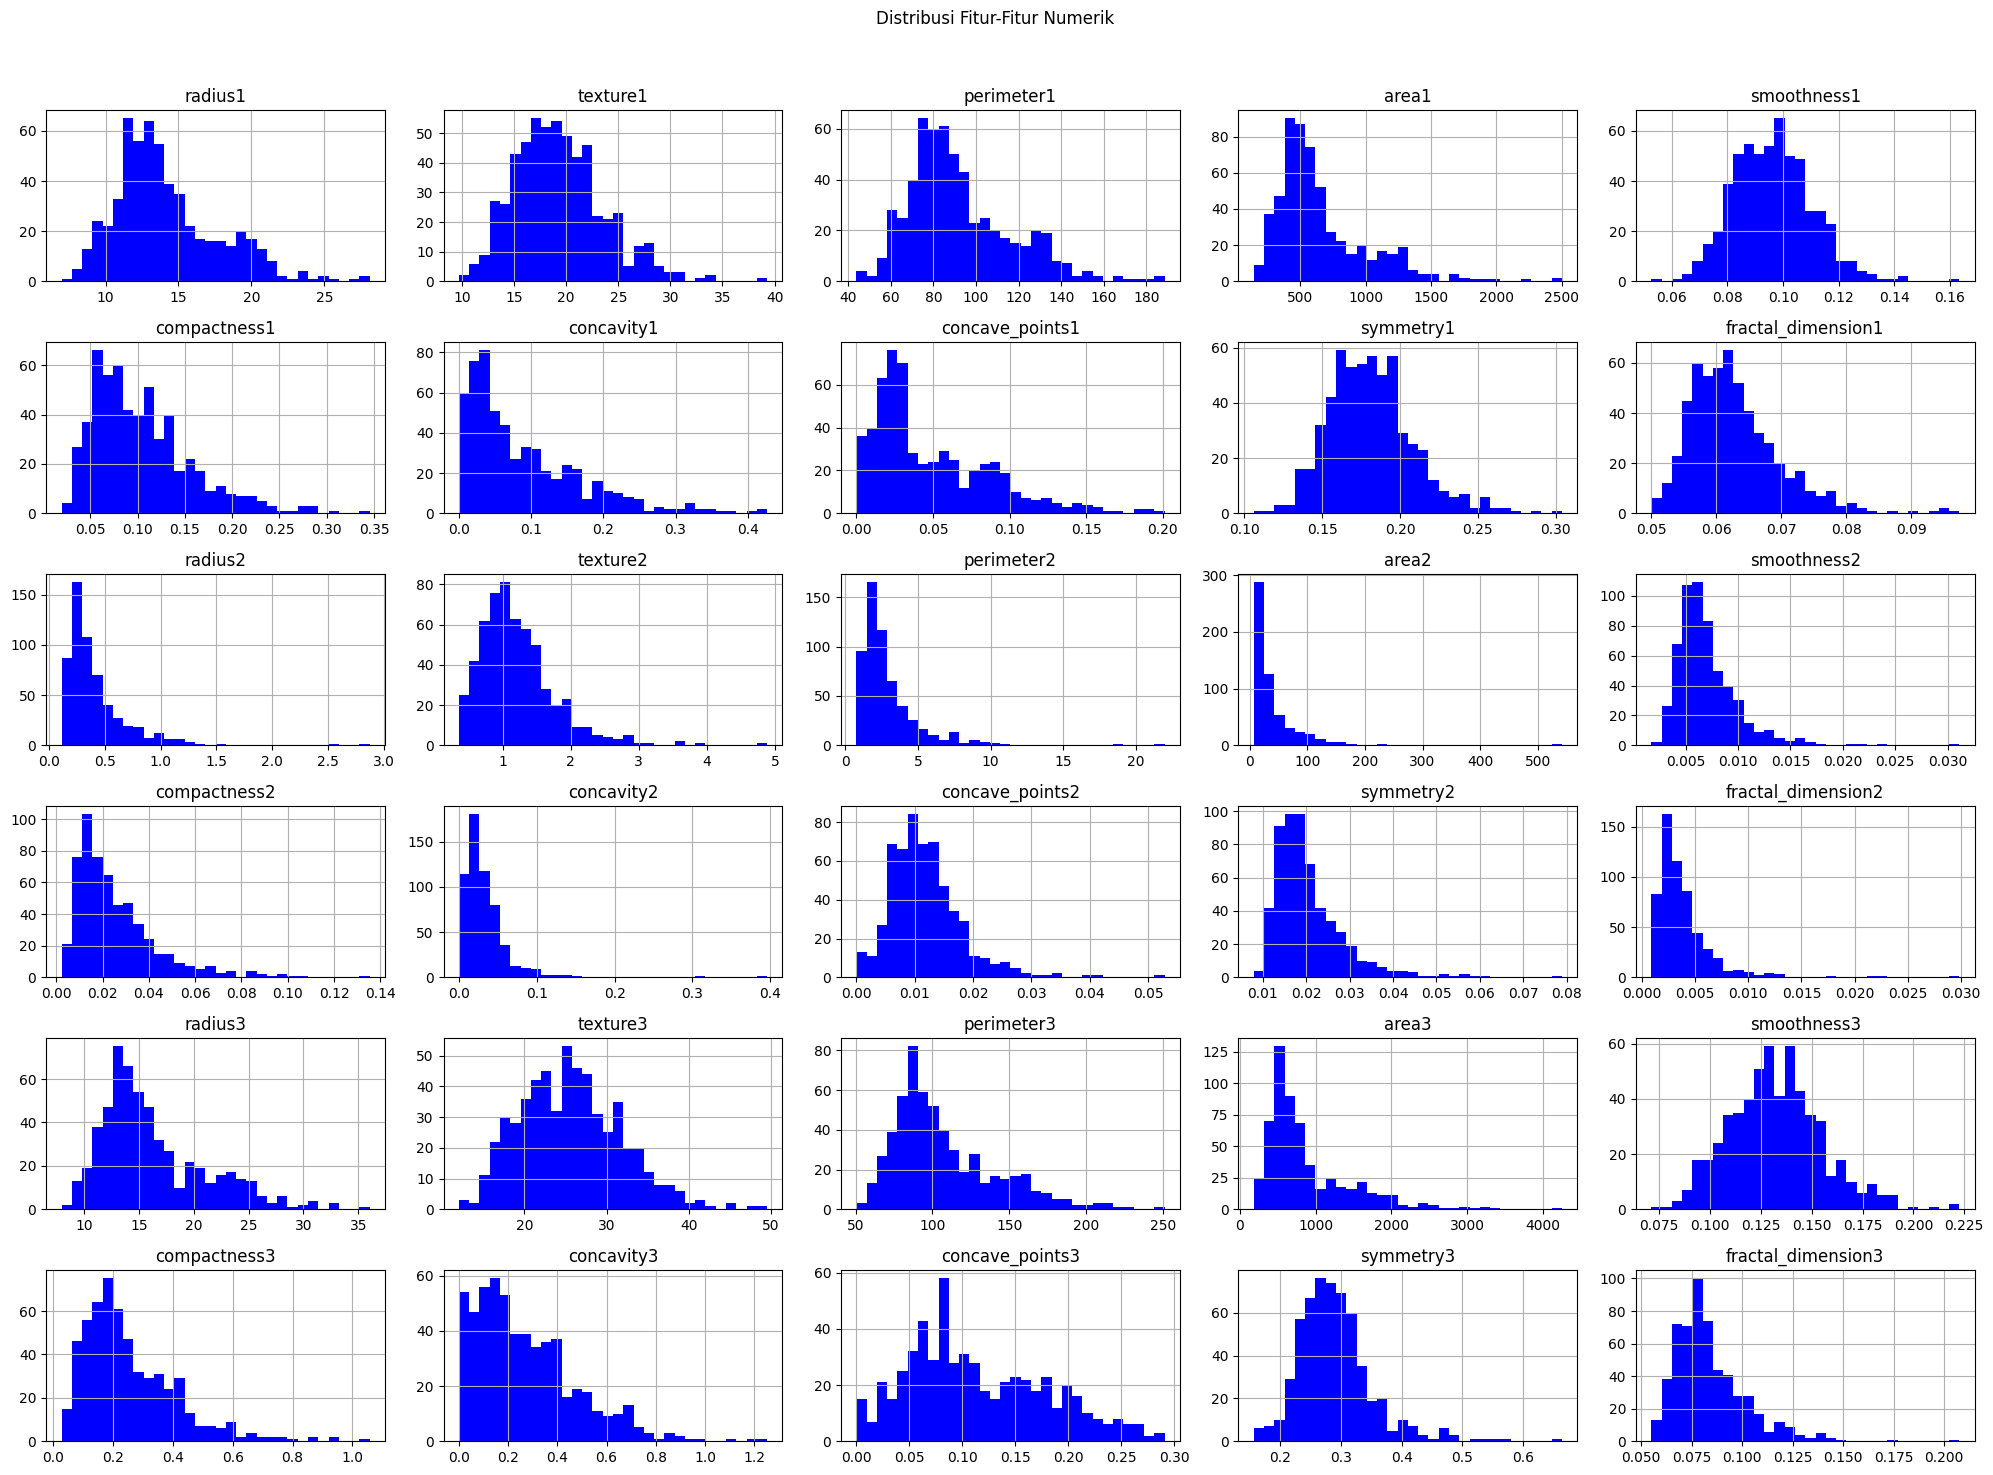

In [ ]:
# Visualisasi distribusi fitur dengan histogram
plt.figure(figsize=(20, 15))
data.drop(['ID', 'Diagnosis'], axis=1).hist(bins=30, figsize=(20, 15), color='blue')
plt.suptitle('Distribusi Fitur-Fitur Numerik')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Struktur Dataset

#### Fitur dan Label

In [ ]:
data.shape #untuk mengetahui bentuk dataset(baris & kolom)

(569, 32)

Terdapat 569 baris dan 32 kolom.

In [ ]:
data.columns #untuk mengetahui kolom-kolom yang ada pada dataset

Index(['ID', 'radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
       'compactness1', 'concavity1', 'concave_points1', 'symmetry1',
       'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2',
       'smoothness2', 'compactness2', 'concavity2', 'concave_points2',
       'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3',
       'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3',
       'symmetry3', 'fractal_dimension3', 'Diagnosis'],
      dtype='object')

**Fitur** adalah atribut atau variabel independen dalam dataset yang digunakan untuk membuat prediksi.

Terdapat 30 fitur numerik pada dataset ini yang dikelompokkan menjadi tiga bagian (nilai rata-rata, standar eror, dan nilai terburuk):
- **radius**: Jarak dari pusat ke titik-titik di perimeter.
- **texture**: Standar deviasi dari nilai skala abu-abu.
- **perimeter**: Panjang perimeter tumor.
- **area**: Luas area tumor.
- **smoothness**: Variasi lokal dalam panjang radius.
- **compactness**: perimeter^2 / area - 1.0.
- **concavity**: Tingkat keparahan bagian cekung dari kontur.
- **concave points**: Jumlah bagian cekung dari kontur.
- **symmetry**: Simetri tumor.
- **fractal dimension**: "coastline approximation" - 1.

**Label** adalah variabel dependen atau target yang ingin diprediksi oleh model. Label merupakan output yang dipelajari oleh model dari data.

Terdapat 1 field label dengan 2 kelas pada dataset ini:

- **Benign (jinak)** dilambangkan dengan huruf **'B'**.

- **Malignant (ganas)** dilambangkan dengan huruf **'M'**.

In [ ]:
data.dtypes #untuk mengetahui tipe data dari masing-masing kolom

,0
ID,int64
radius1,float64
texture1,float64
perimeter1,float64
area1,float64
smoothness1,float64
compactness1,float64
concavity1,float64
concave_points1,float64
symmetry1,float64


In [ ]:
data.groupby('Diagnosis').size() #untuk mengetahui jumlah masing-masing class

,0
Diagnosis,
B,357
M,212


### Identifikasi Kualitas Dataset

#### Deteksi Missing Value

Missing value merupakan data yang hilang pada suatu dataset. Hal ini bisa terjadi oleh beberapa faktor. Kualitas dataset sangat bergantung pada kelengkapan data. Data yang hilang dapat mengurangi kekuatan statistik dari model dan bahkan dapat menghasilkan model yang bias.

Berdasarkan deskripsi dari UCI, dataset ini tidak memiliki nilai yang hilang. Namun, sebagai praktik terbaik, kita akan selalu memverifikasinya secara langsung.

In [ ]:
import pandas as pd

# Deteksi missing values
missing_values = data.isnull()

# Hitung nilai yang hilang di setiap kolom
missing_counts = missing_values.sum()

# Tampilkan jumlah missing value
print("Jumlah Missing Value:")
print(missing_counts[missing_counts > 0])

if missing_counts.sum() == 0:
    print("\nVerifikasi berhasil: Tidak ada missing value dalam dataset ini.")

Jumlah Missing Value:
Series([], dtype: int64)

Verifikasi berhasil: Tidak ada missing value dalam dataset ini.


Berdasarkan proses pengecekan di atas, terkonfirmasi bahwa tidak ada nilai yang hilang di seluruh kolom. Ini menunjukkan kualitas data yang baik dari segi kelengkapan, sehingga kita tidak perlu melakukan teknik imputasi data.

#### Pendeteksian Outlier

Outlier/pencilan merupakan data pada dataset yang menyimpang dari data lainnya. Mendeteksi outlier perlu dilakukan agar data yang diolah memberikan hasil yang baik pada model yang akan dibuat nantinya. Outlier dapat diidentifikasi dan ditangani dengan beberapa cara, salah satunya yang akan kami gunakan yaitu LOF(Local Outlier Factor).

#### Konsep Local Outlier Factor

Outlier adalah titik data yang berbeda atau jauh dari titik data lainnya. Local Outlier Factor (LOF) adalah algoritma yang mengidentifikasi outlier yang ada dalam kumpulan data. Ketika suatu titik dianggap sebagai outlier berdasarkan lingkungan lokalnya, maka titik tersebut disebut local outlier. LOF akan mengidentifikasi outlier dengan mempertimbangkan kepadatan lingkungan. LOF bekerja dengan baik ketika kepadatan data tidak sama di seluruh kumpulan data.

Untuk memahami LOF, ada beberapa konsep yang harus dipelajari secara berurutan:

- K-distance dan K-neighbors
- Reachability Distance (RD)
- Local Reachability Density (LRD)
- Local Outlier Factor (LOF)

#### Implementasi Local Outlier Factor dengan Scikit Learn

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import precision_score
import matplotlib.pyplot as plt
import numpy as np

# Membuat model LOF
# contamination adalah perkiraan proporsi outlier dalam data
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)

# Menggunakan data fitur yang sudah dinormalisasi
X_normalized = data_final.drop('Diagnosis', axis=1)

# Melakukan prediksi outlier
y_pred = lof.fit_predict(X_normalized)
outlier_indices = np.where(y_pred == -1)[0]

print(f"Ditemukan {len(outlier_indices)} outlier.")

# Menampilkan indeks baris yang mengandung outlier
print("Indeks baris yang terdeteksi sebagai outlier:", outlier_indices)

# Menampilkan data pada baris yang mengandung outlier (sebelum normalisasi untuk interpretasi)
outlier_data = data.iloc[outlier_indices]
print("\nData pada baris yang mengandung outlier:")
print(outlier_data.head())

Ditemukan 57 outlier.
Indeks baris yang terdeteksi sebagai outlier: [  0   3   9  12  25  38  42  60  63  68  71  76  78  83 101 108 112 116
 119 122 138 146 150 151 152 176 180 190 192 212 213 239 247 258 265 275
 288 290 314 318 352 376 379 443 461 473 489 491 504 505 520 528 538 539
 561 562 568]

Data pada baris yang mengandung outlier:
          ID  radius1  texture1  perimeter1   area1  smoothness1  \
0     842302    17.99     10.38      122.80  1001.0       0.1184   
3   84348301    11.42     20.38       77.58   386.1       0.1425   
9   84501001    12.46     24.04       83.97   475.9       0.1186   
12    846226    19.17     24.80      132.40  1123.0       0.0974   
25    852631    17.14     16.40      116.00   912.7       0.1186   

    compactness1  concavity1  concave_points1  symmetry1  ...  texture3  \
0         0.2776      0.3001          0.14710     0.2419  ...     17.33   
3         0.2839      0.2414          0.10520     0.2597  ...     26.50   
9         0.2396      0

Penanganan outlier tidak kita lakukan dikarenakan data yang terindikasi outlier bisa jadi merupakan kasus yang valid dan penting secara klinis, sehingga menghapusnya dapat menghilangkan informasi berharga.

## Preprocessing Data

### Tranformasi Data

Dataset di atas nama kelasnya bertipe data kategorikal. Untuk dapat digunakan oleh sebagian besar algoritma *machine learning*, kita perlu mengubahnya menjadi numerik. Misalnya, **0** untuk merepresentasikan kelas *jinak* dan **1** untuk merepresentasikan kelas *ganas*.

Sebagai demonstrasi, kita akan menampilkan data sebelum dan sesudah transformasi.

In [ ]:
data_transformed = data.copy()

print("Data Sebelum Transformasi:")
print(data_transformed[['Diagnosis']].head())

# Mengganti label 'B' menjadi 0 dan 'M' menjadi 1
data_transformed['Diagnosis'] = data_transformed['Diagnosis'].replace({'B': 0, 'M': 1})

print("\nData Setelah Transformasi:")
print(data_transformed[['Diagnosis']].head())

Data Sebelum Transformasi:
  Diagnosis
0         M
1         M
2         M
3         M
4         M

Data Setelah Transformasi:
   Diagnosis
0          1
1          1
2          1
3          1
4          1


/tmp/ipython-input-11-1706018702.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_transformed['Diagnosis'] = data_transformed['Diagnosis'].replace({'B': 0, 'M': 1})


### Normalisasi

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Kita akan menggunakan data yang sudah ditransformasi dan tanpa kolom ID
data_to_normalize = data_transformed.drop('ID', axis=1)

# Memisahkan fitur dari label
X_features = data_to_normalize.drop('Diagnosis', axis=1)
y_label = data_to_normalize['Diagnosis']

# Inisialisasi MinMaxScaler
scaler = MinMaxScaler()

# Normalisasi fitur-fitur numerik
X_normalized = scaler.fit_transform(X_features)

# Membuat DataFrame baru dari data yang telah dinormalisasi
X_normalized_df = pd.DataFrame(X_normalized, columns=X_features.columns)

# Menggabungkan kembali dengan label
data_final = pd.concat([X_normalized_df, y_label.reset_index(drop=True)], axis=1)

# Menyimpan data yang telah dinormalisasi ke dalam file CSV
data_final.to_csv("breast_cancer_diagnostic_normalized.csv", index=False)

# Menampilkan 5 baris pertama data setelah normalisasi
print(data_final.head())

    radius1  texture1  perimeter1     area1  smoothness1  compactness1  \
0  0.521037  0.022658    0.545989  0.363733     0.593753      0.792037   
1  0.643144  0.272574    0.615783  0.501591     0.289880      0.181768   
2  0.601496  0.390260    0.595743  0.449417     0.514309      0.431017   
3  0.210090  0.360839    0.233501  0.102906     0.811321      0.811361   
4  0.629893  0.156578    0.630986  0.489290     0.430351      0.347893   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  texture3  \
0    0.703140         0.731113   0.686364            0.605518  ...  0.141525   
1    0.203608         0.348757   0.379798            0.141323  ...  0.303571   
2    0.462512         0.635686   0.509596            0.211247  ...  0.360075   
3    0.565604         0.522863   0.776263            1.000000  ...  0.385928   
4    0.463918         0.518390   0.378283            0.186816  ...  0.123934   

   perimeter3     area3  smoothness3  compactness3  concavity3  \
0    0.6

## Modelling Klasifikasi Gaussian Naive Bayes

Modeling merupakan proses pembuatan dan pengujian model statistik atau matematis yang digunakan untuk menggambarkan dan menganalisis pola atau hubungan dalam data. Tujuan utama dari pemodelan dalam data mining adalah untuk mengidentifikasi pola yang berguna atau prediksi yang akurat dari data yang tersedia. Untuk modelling kali ini bertujuan untuk menentukan kelas pada suatu data inputan. Data akan dibagi menjadi 2 tipe yaitu data latih dan data uji dan pemodelan kali ini menggunakan metode Gaussian Naive Bayes.

In [ ]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Menggunakan data yang telah diproses (transformasi & normalisasi)
data_model = pd.read_csv('breast_cancer_diagnostic_normalized.csv')

# Memisahkan atribut dan label
X = data_model.drop('Diagnosis', axis=1)
y = data_model['Diagnosis']

# Membagi dataset menjadi data latih & data uji (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membuat model Gaussian Naive Bayes
gnb_model = GaussianNB()

# Melatih model dengan menggunakan data latih
gnb_model.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred = gnb_model.predict(X_test)

print("=========================== Uji Coba Prediksi =================================")
# Mengambil satu sampel dari data uji untuk demonstrasi
sample_index = 0
sample_data = X_test.iloc[[sample_index]]
actual_label = y_test.iloc[sample_index]
predicted_label = gnb_model.predict(sample_data)[0]

print(f"Data yang diuji (sampel ke-{sample_index} dari test set):")
print(sample_data)
print(f"Label Sebenarnya: {int(actual_label)} ({'Ganas' if actual_label==1 else 'Jinak'})")
print(f"Hasil Prediksi Model: {int(predicted_label)} ({'Ganas' if predicted_label==1 else 'Jinak'})")

=========================== Uji Coba Prediksi =================================
Data yang diuji (sampel ke-0 dari test set):
      radius1  texture1  perimeter1     area1  smoothness1  compactness1  \
204  0.259785  0.300643    0.257757  0.143542     0.424483      0.265076   

     concavity1  concave_points1  symmetry1  fractal_dimension1  ...  \
204    0.187559         0.189911   0.436869            0.290017  ...   

      radius3  texture3  perimeter3     area3  smoothness3  compactness3  \
204  0.250445  0.336354    0.227302  0.121092     0.471703      0.204238   

     concavity3  concave_points3  symmetry3  fractal_dimension3  
204    0.213339         0.348797    0.28563            0.212908  

[1 rows x 30 columns]
Label Sebenarnya: 0 (Jinak)
Hasil Prediksi Model: 0 (Jinak)


In [ ]:
# Evaluasi Model secara keseluruhan
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
fscore = f1_score(y_test, y_pred, pos_label=1)

# Menampilkan hasil evaluasi
print(f'Akurasi: {accuracy:.4f}')
print(f'Presisi (untuk kelas Ganas): {precision:.4f}')
print(f'Recall (untuk kelas Ganas): {recall:.4f}')
print(f'F-Score (untuk kelas Ganas): {fscore:.4f}')
print("\nLaporan Klasifikasi Keseluruhan:")
print(classification_report(y_test, y_pred))

Akurasi: 0.9649
Presisi (untuk kelas Ganas): 0.9756
Recall (untuk kelas Ganas): 0.9302
F-Score (untuk kelas Ganas): 0.9524

Laporan Klasifikasi Keseluruhan:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



Dari evaluasi di atas, model Gaussian Naive Bayes mendapatkan akurasi sebesar 96.49%.

## Modeling  dengan Support Vector Machine(SVM)

Support Vector Machine (SVM) adalah metode yang mencari *hyperplane* optimal untuk memisahkan dua kelas data dengan margin maksimum. SVM efektif untuk data dengan jumlah fitur besar dan seringkali memberikan performa yang sangat baik.

In [ ]:
from sklearn.svm import SVC

# Inisialisasi model SVM dengan kernel linear
svm_model = SVC(kernel='linear', random_state=42)

# Melatih model SVM menggunakan data training yang sama
svm_model.fit(X_train, y_train)

# Melakukan prediksi menggunakan data testing
y_pred_svm = svm_model.predict(X_test)

# Evaluasi model SVM
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Akurasi model SVM: {accuracy_svm:.4f}")

print("\nLaporan Klasifikasi Keseluruhan:")
print(classification_report(y_test, y_pred_svm))

Akurasi model SVM: 0.9825

Laporan Klasifikasi Keseluruhan:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Peningkatan Model

Metode ensemble merupakan penggabungan beberapa *classifier* individual untuk membentuk *classifier* baru sehingga didapatkan hasil yang lebih akurat. Kita akan menggunakan **Stacking** dan **Bagging** untuk mencoba meningkatkan performa.

### Stacking Classifier(Meta Classifier)

Stacking melibatkan penggabungan beberapa model berbeda dan menggunakan model yang lebih tinggi (meta-model) untuk menggabungkan hasil prediksi dari model-model tersebut. Kita akan menggunakan kombinasi KNN dan SVM sebagai model dasar, dan GNB sebagai meta-model.

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Definisikan model-model dasar
estimators = [
    ('knn_5', KNeighborsClassifier(n_neighbors=5)),
    ('svm_lin', SVC(kernel='linear', probability=True, random_state=42)),
    ('svm_rbf', SVC(kernel='rbf', probability=True, random_state=42))
]

# Inisialisasi StackingClassifier dengan GaussianNB sebagai meta-model
stacking_clf = StackingClassifier(
    estimators=estimators, final_estimator=GaussianNB(), cv=5
)

# Melatih StackingClassifier
stacking_clf.fit(X_train, y_train)

# Prediksi dan Evaluasi
y_pred_stacking = stacking_clf.predict(X_test)
accuracy_stacking = accuracy_score(y_test, y_pred_stacking)

print(f'Akurasi Model Stacking: {accuracy_stacking:.4f}')
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred_stacking))

Akurasi Model Stacking: 0.9561

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96        71
           1       0.93      0.95      0.94        43

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



### Bagging

Bagging (Bootstrap Aggregating) melatih beberapa model yang sama pada subset data yang berbeda. Prediksi akhir ditentukan oleh *majority vote* (untuk klasifikasi). Metode ini bertujuan untuk mengurangi varians dan overfitting. Kita akan menggunakan SVM sebagai model dasar untuk Bagging.

In [ ]:
from sklearn.ensemble import BaggingClassifier

# Inisialisasi BaggingClassifier dengan SVM sebagai model dasar
# Kita akan membuat 20 model SVM
bagging_clf = BaggingClassifier(estimator=SVC(kernel='linear', random_state=42), n_estimators=20, random_state=42)

# Melatih BaggingClassifier
bagging_clf.fit(X_train, y_train)

# Prediksi dan Evaluasi
y_pred_bagging = bagging_clf.predict(X_test)
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)

print(f'Akurasi Model Bagging (SVM): {accuracy_bagging:.4f}')
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred_bagging))

Akurasi Model Bagging (SVM): 0.9825

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Evaluasi

Dari keempat model yang dibuat dapat dilihat akurasi dari masing-masing model, yaitu:

- Single model GNB: 96.49%
- Single model SVM: 98.25%
- Stacking (KNN + SVMs, meta: GNB): 95.61%
- Bagging dengan SVM: 98.25%

Dari keempat model di atas, dapat disimpulkan bahwa **model SVM tunggal** memiliki akurasi tertinggi yaitu **98.25%**. Model ini menunjukkan performa terbaik pada dataset ini.

## Deployment

### Menyimpan Model

Pada tahap ini saya akan menyimpan model dari *single model SVM* yang sudah dibuat. Tujuan dilakukan penyimpanan model adalah supaya mudah dipanggil ketika akan memasuki tahap deployment. Untuk menyimpan model, saya menggunakan library `joblib`.

In [ ]:
import joblib

# Save the model to a file
joblib.dump(svm_model, 'svm_diagnostic_model.pkl')

['svm_diagnostic_model.pkl']